# Análise Exploratória das Avaliações da Steam

Este notebook apresenta as etapas de preparação, exploração e análise inicial
das avaliações de usuários da plataforma Steam. A base será posteriormente
utilizada nas etapas de Processamento de Linguagem Natural (NLP) e classificação
automática das avaliações.

## 1. Importação das bibliotecas

Nesta etapa são carregadas as bibliotecas necessárias para leitura dos dados,
manipulação das informações e realização das análises exploratórias.

In [21]:
import gzip
import json
from pathlib import Path
import pandas as pd

### Bibliotecas utilizadas

As principais bibliotecas utilizadas no projeto são:

- `pandas`: leitura, organização e análise dos dados;
- `scikit-learn`: preparação dos dados, TF-IDF, treinamento dos modelos e cálculo das métricas;
- `matplotlib`: criação dos gráficos;
- `seaborn`: visualização das matrizes de confusão;
- `gzip`: leitura do arquivo JSON compactado;
- `json`: leitura e manipulação dos dados em formato JSON;
- `pathlib`: definição dos caminhos dos arquivos;
- `re`: limpeza e normalização dos textos.

## 2. Definição dos arquivos utilizados

Nesta etapa são definidos os caminhos dos arquivos que serão utilizados no
projeto. O trabalho será desenvolvido exclusivamente com a base de avaliações
da Steam, não sendo utilizado o dataset adicional de jogos.

In [22]:
PASTA_PROJETO = Path.cwd().parent  # Sobe um nível a partir da pasta 'notebooks'

ARQUIVO_REVIEWS = (
    PASTA_PROJETO
    / "Data"
    / "steam_2025_5k-dataset-reviews_20250901.json.gz"
)

print("Arquivo de reviews:", ARQUIVO_REVIEWS)
print("Arquivo existe?", ARQUIVO_REVIEWS.exists())

Arquivo de reviews: c:\Users\Francisco PC\OneDrive\Documentos\GitHub\projeto-aplicado-II-classificacoes-avaliacoes\Data\steam_2025_5k-dataset-reviews_20250901.json.gz
Arquivo existe? True


## 3. Carregamento das avaliações

O arquivo de avaliações está armazenado em formato JSON compactado (`.json.gz`).
Nesta etapa, os dados são carregados em memória para posterior transformação
e análise.

In [23]:
# Carregar o dataset de avaliações
with gzip.open(ARQUIVO_REVIEWS, "rt", encoding="utf-8") as arquivo:
    dados_reviews = json.load(arquivo)

print("\nArquivo de reviews carregado com sucesso!")
print("Chaves principais:", list(dados_reviews.keys()))


Arquivo de reviews carregado com sucesso!
Chaves principais: ['metadata', 'reviews']


## 4. Estruturação dos dados

As avaliações carregadas são transformadas em um DataFrame do pandas, estrutura
que facilita a manipulação, exploração e análise dos dados ao longo do projeto.

In [24]:
linhas = []

for item in dados_reviews["reviews"]:
    appid = item["appid"]
    dados = item["review_data"]

    for review in dados["reviews"]:
        registro = review.copy()
        registro["appid"] = appid
        linhas.append(registro)

df_reviews = pd.DataFrame(linhas)

print(f"DataFrame criado com {len(df_reviews)} linhas e {len(df_reviews.columns)} colunas.")
display(df_reviews.head(3))

DataFrame criado com 37778 linhas e 18 colunas.


,recommendationid,author,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,appid,timestamp_dev_responded,developer_response
0,201194290,"{'steamid': '76561198152964416', 'num_games_ow...",russian,Я верю что однажды капитализм очиститься и люд...,1754033180,1754033180,True,58,2,0.834045231342315674,2,True,False,False,False,2210,NaN,NaN
1,202221261,"{'steamid': '76561198060071144', 'num_games_ow...",brazilian,Jogo é bom no geral. Mas uma pena não ter se q...,1755311121,1755311121,True,4,0,0.583333313465118408,0,True,False,False,False,2210,NaN,NaN
2,201240332,"{'steamid': '76561197965801053', 'num_games_ow...",english,This game feels like a mix of Quake 2+3 and so...,1754084409,1754084409,True,8,0,0.54731827974319458,0,True,False,False,False,2210,NaN,NaN


## 5. Distribuição das recomendações

A variável `voted_up` indica se o usuário recomendou ou não o jogo. O valor
`True` representa uma recomendação positiva, enquanto `False` representa uma
recomendação negativa.

A análise dessa variável é importante porque ela será utilizada posteriormente
como variável-alvo na tarefa de classificação automática das avaliações.

In [25]:
df_reviews["voted_up"].value_counts()

voted_up
True     28546
False     9232
Name: count, dtype: int64

In [26]:
print("========================================")
print("DISTRIBUIÇÃO DAS RECOMENDAÇÕES")
print("========================================")

print(df_reviews["voted_up"].value_counts())

print("\nPercentual (%):")
display(
    df_reviews["voted_up"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

DISTRIBUIÇÃO DAS RECOMENDAÇÕES
voted_up
True     28546
False     9232
Name: count, dtype: int64

Percentual (%):


voted_up
True     75.56
False    24.44
Name: proportion, dtype: float64

## 6. Distribuição dos idiomas

Nesta etapa é analisada a distribuição dos idiomas presentes nas avaliações.
Essa informação é utilizada para definir o recorte linguístico da análise.

Para as etapas de Processamento de Linguagem Natural, serão utilizadas
avaliações em inglês, buscando reduzir a complexidade linguística e manter
maior consistência no processamento dos textos.

In [27]:
print("========================================")
print("IDIOMAS MAIS FREQUENTES")
print("========================================")

display(df_reviews["language"].value_counts().head(15))

IDIOMAS MAIS FREQUENTES


language
english      19487
schinese      5209
russian       3756
german        1441
brazilian     1193
spanish       1073
japanese       932
french         927
koreana        873
turkish        650
tchinese       507
polish         467
latam          252
italian        240
czech          142
Name: count, dtype: int64

## 7. Período das avaliações

O campo `timestamp_created` contém o momento em que cada avaliação foi
publicada. O timestamp Unix é convertido para o formato de data utilizando
a biblioteca pandas.

Essa transformação permite analisar a distribuição temporal das avaliações
e definir o período utilizado no estudo.

In [28]:
df_reviews["data"] = pd.to_datetime(
    df_reviews["timestamp_created"],
    unit="s"
)

print("========================================")
print("PERÍODO DAS AVALIAÇÕES")
print("========================================")
print("Primeira avaliação:", df_reviews["data"].min())
print("Última avaliação:", df_reviews["data"].max())

PERÍODO DAS AVALIAÇÕES
Primeira avaliação: 2010-11-20 20:38:46
Última avaliação: 2025-09-01 06:47:21


## 8. Distribuição das avaliações por ano

Após a conversão das datas, é extraído o ano de publicação de cada avaliação.
A quantidade de avaliações por ano permite observar a disponibilidade dos dados
ao longo do período analisado.

In [29]:
df_reviews["ano"] = df_reviews["data"].dt.year

print("========================================")
print("AVALIAÇÕES POR ANO")
print("========================================")

display(
    df_reviews["ano"]
    .value_counts()
    .sort_index()
)

AVALIAÇÕES POR ANO


ano
2010        5
2011       30
2012       43
2013      113
2014      656
2015      894
2016     1312
2017     2690
2018     2118
2019     2151
2020     2493
2021     2671
2022     2636
2023     2207
2024     2279
2025    15480
Name: count, dtype: int64

## 9. Análise do tamanho dos textos

Nesta etapa é calculada a quantidade de palavras presente em cada avaliação.
Essa análise permite conhecer a extensão dos textos e identificar possíveis
avaliações muito curtas antes da aplicação das técnicas de NLP.

Neste momento, avaliações curtas não são removidas; apenas são identificadas
e quantificadas para apoiar decisões posteriores.

In [30]:
df_reviews["quantidade_palavras"] = (
    df_reviews["review"]
    .fillna("")
    .str.split()
    .str.len()
)

print("========================================")
print("ESTATÍSTICA DO TAMANHO DOS TEXTOS")
print("========================================")

display(df_reviews["quantidade_palavras"].describe())

ESTATÍSTICA DO TAMANHO DOS TEXTOS


count    37778.000000
mean        59.664964
std        116.518534
min          0.000000
25%          5.000000
50%         20.000000
75%         62.000000
max       3458.000000
Name: quantidade_palavras, dtype: float64

## 10. Verificação de valores ausentes

A qualidade dos dados é verificada por meio da identificação de valores
ausentes em cada variável da base.

Essa etapa permite avaliar possíveis limitações dos dados e verificar se
campos importantes para a análise apresentam informações faltantes.

In [31]:
print("========================================")
print("MAPEAMENTO DE VALORES AUSENTES")
print("========================================")

display(
    df_reviews.isnull()
    .sum()
    .sort_values(ascending=False)
)

MAPEAMENTO DE VALORES AUSENTES


developer_response             36867
timestamp_dev_responded        36867
language                           0
author                             0
recommendationid                   0
timestamp_created                  0
review                             0
timestamp_updated                  0
voted_up                           0
weighted_vote_score                0
comment_count                      0
votes_up                           0
votes_funny                        0
received_for_free                  0
steam_purchase                     0
primarily_steam_deck               0
written_during_early_access        0
appid                              0
data                               0
ano                                0
quantidade_palavras                0
dtype: int64

## 11. Recorte por idioma

Para a etapa de Processamento de Linguagem Natural (NLP), serão consideradas
as avaliações escritas em inglês. A utilização de um único idioma reduz a
complexidade do processamento textual e mantém maior consistência linguística
na análise e na classificação das avaliações.

In [32]:
print("========================================")
print("RECORTE POR IDIOMA")
print("========================================")

df_ingles = df_reviews[
    df_reviews["language"] == "english"
].copy()

print("Avaliações em inglês:", len(df_ingles))

RECORTE POR IDIOMA
Avaliações em inglês: 19487


## 12. Distribuição temporal das avaliações em inglês

Após a seleção das avaliações em inglês, analisamos sua distribuição ao longo
dos anos para verificar a disponibilidade de dados no período considerado.

In [33]:
print("========================================")
print("AVALIAÇÕES EM INGLÊS POR ANO")
print("========================================")

display(
    df_ingles["ano"]
    .value_counts()
    .sort_index()
)

AVALIAÇÕES EM INGLÊS POR ANO


ano
2010       5
2011      18
2012      35
2013      90
2014     447
2015     602
2016     794
2017    1459
2018    1088
2019    1118
2020    1343
2021    1339
2022    1446
2023    1221
2024    1256
2025    7226
Name: count, dtype: int64

## 13. Definição do período de análise

O período de análise foi definido entre 2010 e 2025, abrangendo todo o
intervalo temporal disponível na base de avaliações em inglês.

A manutenção do período completo permite aproveitar a maior quantidade
possível de avaliações e observar a evolução das opiniões dos usuários ao
longo do tempo.

In [34]:
print("========================================")
print("RECORTE TEMPORAL")
print("========================================")

df_final = df_ingles[
    df_ingles["ano"].between(2010, 2025)
].copy()

print("Avaliações após o recorte:", len(df_final))
print("Primeiro ano:", df_final["ano"].min())
print("Último ano:", df_final["ano"].max())

RECORTE TEMPORAL
Avaliações após o recorte: 19487
Primeiro ano: 2010
Último ano: 2025


## 14. Distribuição da variável-alvo

A variável `voted_up` representa a recomendação realizada pelo usuário na
Steam. O valor `True` indica uma recomendação positiva, enquanto `False`
indica uma recomendação negativa.

Essa variável será utilizada posteriormente como variável-alvo para os
modelos de classificação.

In [35]:
print("========================================")
print("DISTRIBUIÇÃO DA RECOMENDAÇÃO - BASE FINAL")
print("========================================")

display(
    df_final["voted_up"].value_counts()
)

print("\nPercentual (%):")

display(
    df_final["voted_up"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

DISTRIBUIÇÃO DA RECOMENDAÇÃO - BASE FINAL


voted_up
True     14613
False     4874
Name: count, dtype: int64


Percentual (%):


voted_up
True     74.99
False    25.01
Name: proportion, dtype: float64

## 15. Qualidade e tamanho dos textos

Antes da aplicação das técnicas de Processamento de Linguagem Natural,
analisamos o tamanho das avaliações para identificar a distribuição dos
textos e possíveis avaliações excessivamente curtas.

In [36]:
print("========================================")
print("ESTATÍSTICA DO TAMANHO DOS TEXTOS")
print("========================================")

display(
    df_final["quantidade_palavras"].describe()
)

ESTATÍSTICA DO TAMANHO DOS TEXTOS


count    19487.000000
mean        78.963771
std        130.146754
min          0.000000
25%         13.000000
50%         35.000000
75%         88.000000
max       1471.000000
Name: quantidade_palavras, dtype: float64

## 16. Avaliações muito curtas

A quantidade de palavras é analisada para identificar avaliações com pouco
conteúdo textual. Neste momento, essas avaliações não serão removidas,
apenas quantificadas para apoiar decisões posteriores relacionadas ao
processamento de linguagem natural.

In [37]:
print("========================================")
print("TEXTOS MUITO CURTOS - BASE FINAL")
print("========================================")

for limite in [0, 1, 2, 3, 5, 10]:
    quantidade = (
        df_final["quantidade_palavras"] <= limite
    ).sum()

    percentual = quantidade / len(df_final) * 100

    print(
        f"Até {limite} palavras: "
        f"{quantidade} ({percentual:.2f}%)"
    )

TEXTOS MUITO CURTOS - BASE FINAL
Até 0 palavras: 10 (0.05%)
Até 1 palavras: 651 (3.34%)
Até 2 palavras: 1140 (5.85%)
Até 3 palavras: 1579 (8.10%)
Até 5 palavras: 2370 (12.16%)
Até 10 palavras: 4103 (21.06%)


## 17. Verificação de duplicidades

A presença de avaliações duplicadas pode introduzir viés na análise e no
treinamento dos modelos. Por isso, verificamos a existência de avaliações
textualmente duplicadas na base final.

In [38]:
print("========================================")
print("VERIFICAÇÃO DE DUPLICIDADES")
print("========================================")

duplicadas = df_final.duplicated(
    subset=["review"]
).sum()

print("Reviews duplicadas:", duplicadas)

VERIFICAÇÃO DE DUPLICIDADES
Reviews duplicadas: 384


## 18. Resumo da base definitiva

Após as etapas de seleção e validação, consolidamos as principais
características da base que será utilizada nas etapas seguintes do projeto.

In [39]:
print("========================================")
print("RESUMO DA BASE FINAL")
print("========================================")

print("Avaliações:", len(df_final))
print("Período:", df_final["ano"].min(), "a", df_final["ano"].max())
print("Idioma: Inglês")

print(
    "Recomendação positiva:",
    (df_final["voted_up"] == True).sum()
)

print(
    "Recomendação negativa:",
    (df_final["voted_up"] == False).sum()
)

print(
    "Reviews duplicadas:",
    df_final.duplicated(subset=["review"]).sum()
)

RESUMO DA BASE FINAL
Avaliações: 19487
Período: 2010 a 2025
Idioma: Inglês
Recomendação positiva: 14613
Recomendação negativa: 4874
Reviews duplicadas: 384


## 19. Preparação da base para modelagem

A partir da base definitiva, será criada uma nova base específica para a etapa de modelagem.

A coluna `review` será utilizada como variável de entrada, pois contém o texto escrito pelos usuários. A coluna `voted_up` será utilizada como variável-alvo, indicando se o usuário recomendou ou não o jogo.

A base original será preservada para manter as informações utilizadas na análise exploratória.

In [40]:
df_modelo = df_final[
    ["review", "voted_up"]
].copy()

print("Quantidade de registros:", len(df_modelo))
print("\nColunas utilizadas:")
print(df_modelo.columns.tolist())

display(df_modelo.head())

Quantidade de registros: 19487

Colunas utilizadas:
['review', 'voted_up']


,review,voted_up
2,This game feels like a mix of Quake 2+3 and so...,True
3,Suprisingly fun but stained with typical earl...,True
4,When I first played it back in 2005 I was very...,True
6,"I played this game when I was little, but didn...",True
7,As one of the most underrated sequels of all t...,True


## 20. Verificação dos textos

Antes do processamento, será verificada a existência de valores ausentes ou avaliações sem conteúdo.

Essa verificação é necessária porque o texto da avaliação será utilizado como principal variável de entrada dos modelos.

In [41]:
print("========================================")
print("VERIFICAÇÃO DOS TEXTOS")
print("========================================")

print("Valores nulos em review:", df_modelo["review"].isna().sum())

print(
    "Reviews vazias:",
    (df_modelo["review"].fillna("").str.strip() == "").sum()
)

VERIFICAÇÃO DOS TEXTOS
Valores nulos em review: 0
Reviews vazias: 10


## 21. Limpeza e normalização dos textos

Os textos serão convertidos para letras minúsculas e passarão por uma limpeza inicial para remover URLs, caracteres desnecessários e espaços extras.

Neste momento, não serão removidas stopwords, pois algumas palavras podem contribuir para a classificação das avaliações.

In [42]:
import re

def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"[^a-zA-ZÀ-ÿ\s']", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()


df_modelo["review_limpa"] = (
    df_modelo["review"]
    .fillna("")
    .apply(limpar_texto)
)

display(
    df_modelo[["review", "review_limpa"]].head(10)
)

,review,review_limpa
2,This game feels like a mix of Quake 2+3 and so...,this game feels like a mix of quake and some d...
3,Suprisingly fun but stained with typical earl...,suprisingly fun but stained with typical early...
4,When I first played it back in 2005 I was very...,when i first played it back in i was very disa...
6,"I played this game when I was little, but didn...",i played this game when i was little but didn'...
7,As one of the most underrated sequels of all t...,as one of the most underrated sequels of all t...
8,I have loved this game for years and still lov...,i have loved this game for years and still lov...
9,An absolute classic! One of my favourite FPS e...,an absolute classic one of my favourite fps ex...
12,"rad, it's so fun, a great way to get immersed ...",rad it's so fun a great way to get immersed in...
14,Quake 4 is....fine. There's nothing really wr...,quake is fine there's nothing really wrong abo...
19,This is a 2005 game and you can feel it in eve...,this is a game and you can feel it in every ti...


## 22. Verificação após a limpeza

Após a normalização, será verificado se algum texto ficou vazio. Esses registros não possuem informação textual suficiente para serem utilizados na modelagem.

In [43]:
textos_vazios = (
    df_modelo["review_limpa"]
    .str.strip()
    .eq("")
    .sum()
)

print("Textos vazios após a limpeza:", textos_vazios)

Textos vazios após a limpeza: 262


## 23. Remoção de textos sem conteúdo

Após a limpeza e normalização, foram identificadas 262 avaliações que ficaram sem conteúdo textual.

Como a coluna `review_limpa` será utilizada como entrada para a vetorização TF-IDF e posteriormente para os modelos de classificação, esses registros não possuem informação textual suficiente para participar da modelagem.

Por esse motivo, essas avaliações serão removidas da base utilizada no treinamento dos modelos.

In [44]:
df_modelo = df_modelo[
    df_modelo["review_limpa"].str.strip() != ""
].copy()

print("Registros após a remoção dos textos vazios:", len(df_modelo))

Registros após a remoção dos textos vazios: 19225


In [45]:
print("Registros em df_final:", len(df_final))
print("Registros em df_modelo:", len(df_modelo))

print("\nPeríodo:")
print(df_final["ano"].min(), "até", df_final["ano"].max())

print("\nDistribuição da variável-alvo:")
print(df_modelo["voted_up"].value_counts())

Registros em df_final: 19487
Registros em df_modelo: 19225

Período:
2010 até 2025

Distribuição da variável-alvo:
voted_up
True     14391
False     4834
Name: count, dtype: int64


## 24. Preparação da variável-alvo

A variável `voted_up` será utilizada como variável-alvo do modelo.

Ela indica se o usuário recomendou o jogo. Para facilitar o processamento pelos modelos de classificação, os valores serão convertidos para uma representação numérica:

- `1` representa uma recomendação positiva;
- `0` representa uma recomendação negativa.

In [46]:
df_modelo["alvo"] = df_modelo["voted_up"].astype(int)

print("Distribuição da variável-alvo:")
print(df_modelo["alvo"].value_counts())

print("\nDistribuição percentual:")
print(
    df_modelo["alvo"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Distribuição da variável-alvo:
alvo
1    14391
0     4834
Name: count, dtype: int64

Distribuição percentual:
alvo
1    74.86
0    25.14
Name: proportion, dtype: float64


## 25. Método Analítico

O método analítico escolhido para o projeto é a classificação supervisionada.

A classificação supervisionada utiliza dados que possuem uma variável-alvo conhecida para treinar um modelo capaz de realizar previsões em novos registros.

Neste projeto, o texto das avaliações será utilizado como informação de entrada e a variável `voted_up` será utilizada como variável-alvo. O objetivo é identificar se uma avaliação corresponde a uma recomendação positiva ou negativa.

Como as avaliações possuem uma classificação conhecida, o modelo poderá aprender padrões presentes nos textos associados a cada classe.

## 26. Transformação dos textos com TF-IDF

As avaliações são compostas por textos e precisam ser transformadas em uma representação numérica antes de serem utilizadas pelos modelos de classificação.

Para isso será utilizada a técnica TF-IDF (Term Frequency-Inverse Document Frequency).

O TF-IDF atribui pesos às palavras de acordo com sua frequência nos textos e sua relevância dentro do conjunto de avaliações. Dessa forma, palavras que aparecem com frequência em muitos textos tendem a receber menor peso, enquanto termos mais específicos podem receber maior importância.

A representação gerada pelo TF-IDF será utilizada como entrada para os modelos de classificação.

## 27. Separação dos dados

A base será dividida em dois conjuntos:

- dados de treinamento, utilizados para ajustar os modelos;
- dados de teste, utilizados posteriormente para avaliar o desempenho dos modelos em dados que não participaram do treinamento.

A separação será realizada mantendo a proporção das classes positivas e negativas por meio da estratificação da variável-alvo.

In [47]:
from sklearn.model_selection import train_test_split

X = df_modelo["review_limpa"]
y = df_modelo["alvo"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treinamento:", len(X_treino))
print("Teste:", len(X_teste))

Treinamento: 15380
Teste: 3845


## 28. Vetorização TF-IDF

A técnica TF-IDF será aplicada aos textos de treinamento e teste.

O vetor será ajustado somente com os dados de treinamento. Em seguida, a mesma transformação será aplicada aos dados de teste.

Essa separação evita que informações do conjunto de teste sejam utilizadas durante o treinamento dos modelos.

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_treino_tfidf = tfidf.fit_transform(X_treino)
X_teste_tfidf = tfidf.transform(X_teste)

print("Formato dos dados de treinamento:", X_treino_tfidf.shape)
print("Formato dos dados de teste:", X_teste_tfidf.shape)

Formato dos dados de treinamento: (15380, 5000)
Formato dos dados de teste: (3845, 5000)


## 29. Modelos de classificação

Serão testados modelos de classificação supervisionada para identificar se uma avaliação da Steam representa uma recomendação positiva ou negativa.

Os modelos inicialmente selecionados são:

- Multinomial Naive Bayes;
- Regressão Logística;
- Random Forest.

A comparação entre os modelos será realizada posteriormente por meio das métricas de avaliação definidas no projeto.

## 30. Multinomial Naive Bayes

O Multinomial Naive Bayes é um modelo de classificação probabilística que pode ser utilizado em problemas envolvendo dados textuais.

O modelo calcula a probabilidade de um texto pertencer a cada classe com base nas características observadas nos dados de treinamento.

Neste projeto, será utilizado sobre a representação TF-IDF das avaliações para classificar as reviews como positivas ou negativas.

## 31. Regressão Logística

A Regressão Logística é um modelo de classificação utilizado para estimar a probabilidade de um registro pertencer a uma determinada classe.

No projeto, o modelo receberá os valores gerados pelo TF-IDF e será utilizado para classificar as avaliações entre recomendações positivas e negativas.

## 32. Random Forest

Random Forest é um método baseado na combinação de várias árvores de decisão.

Cada árvore realiza uma classificação e os resultados são combinados para produzir a classificação final.

Neste projeto, o modelo será utilizado para testar uma abordagem diferente dos modelos probabilístico e linear na classificação das avaliações.

## 33. Treinamento dos modelos

Após a preparação dos textos e a aplicação da técnica TF-IDF, os dados serão utilizados para treinar os modelos de classificação selecionados.

O treinamento será realizado com os dados do conjunto de treino. Em seguida, os modelos serão utilizados para realizar previsões sobre o conjunto de teste, que será utilizado na avaliação dos resultados.

Serão treinados os seguintes modelos:

- Multinomial Naive Bayes;
- Regressão Logística;
- Random Forest.

In [49]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Criando os modelos
modelo_nb = MultinomialNB()

modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Treinamento
modelo_nb.fit(X_treino_tfidf, y_treino)
modelo_lr.fit(X_treino_tfidf, y_treino)
modelo_rf.fit(X_treino_tfidf, y_treino)

print("Treinamento dos modelos concluído com sucesso.")

Treinamento dos modelos concluído com sucesso.


## 34. Previsões dos modelos

Após o treinamento, os modelos serão utilizados para realizar previsões sobre o conjunto de teste.

As previsões serão comparadas com os valores reais de `y_teste` para avaliar o desempenho de cada modelo.

In [50]:
# Realizar as previsões
previsoes_nb = modelo_nb.predict(X_teste_tfidf)
previsoes_lr = modelo_lr.predict(X_teste_tfidf)
previsoes_rf = modelo_rf.predict(X_teste_tfidf)

print("Previsões realizadas com sucesso.")

Previsões realizadas com sucesso.


## 35. Cálculo da Acurácia

A acurácia será utilizada para medir a proporção de classificações corretas realizadas pelo modelo em relação ao total de previsões.

A métrica será calculada pela seguinte fórmula:

**Acurácia = (VP + VN) / (VP + VN + FP + FN)**

Onde:

- VP = Verdadeiros Positivos;
- VN = Verdadeiros Negativos;
- FP = Falsos Positivos;
- FN = Falsos Negativos.

Quanto maior a proporção de classificações corretas em relação ao total de previsões, maior será o valor da acurácia.

In [51]:
from sklearn.metrics import accuracy_score

acuracia_nb = accuracy_score(y_teste, previsoes_nb)
acuracia_lr = accuracy_score(y_teste, previsoes_lr)
acuracia_rf = accuracy_score(y_teste, previsoes_rf)

print("Acurácia dos modelos:")
print(f"Multinomial Naive Bayes: {acuracia_nb:.4f} ({acuracia_nb:.2%})")
print(f"Regressão Logística:     {acuracia_lr:.4f} ({acuracia_lr:.2%})")
print(f"Random Forest:           {acuracia_rf:.4f} ({acuracia_rf:.2%})")

Acurácia dos modelos:
Multinomial Naive Bayes: 0.8408 (84.08%)
Regressão Logística:     0.8629 (86.29%)
Random Forest:           0.8289 (82.89%)


## 36. Avaliação dos modelos

Além da acurácia, serão utilizadas as métricas de Precisão, Recall e F1-Score para avaliar o desempenho dos modelos.

A análise conjunta dessas métricas permitirá observar o comportamento dos modelos nas classificações positivas e negativas, evitando que a avaliação seja baseada somente na quantidade total de previsões corretas.

In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score

modelos = {
    "Multinomial Naive Bayes": previsoes_nb,
    "Regressão Logística": previsoes_lr,
    "Random Forest": previsoes_rf
}

for nome, previsoes in modelos.items():
    precisao = precision_score(y_teste, previsoes)
    recall = recall_score(y_teste, previsoes)
    f1 = f1_score(y_teste, previsoes)

    print(f"\n{nome}")
    print(f"Precisão: {precisao:.4f} ({precisao:.2%})")
    print(f"Recall:   {recall:.4f} ({recall:.2%})")
    print(f"F1-Score: {f1:.4f} ({f1:.2%})")


Multinomial Naive Bayes
Precisão: 0.8326 (83.26%)
Recall:   0.9854 (98.54%)
F1-Score: 0.9026 (90.26%)

Regressão Logística
Precisão: 0.8688 (86.88%)
Recall:   0.9621 (96.21%)
F1-Score: 0.9131 (91.31%)

Random Forest
Precisão: 0.8272 (82.72%)
Recall:   0.9750 (97.50%)
F1-Score: 0.8951 (89.51%)


## 37. Matriz de Confusão

A matriz de confusão será utilizada para verificar como cada modelo classificou as avaliações em relação às classes positiva e negativa.

A matriz permite identificar:

- Verdadeiros Positivos (VP);
- Verdadeiros Negativos (VN);
- Falsos Positivos (FP);
- Falsos Negativos (FN).

Essa análise complementa as métricas anteriores, permitindo observar quais tipos de erro estão ocorrendo nas previsões.

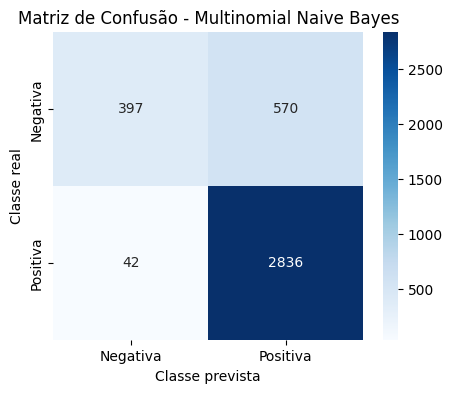

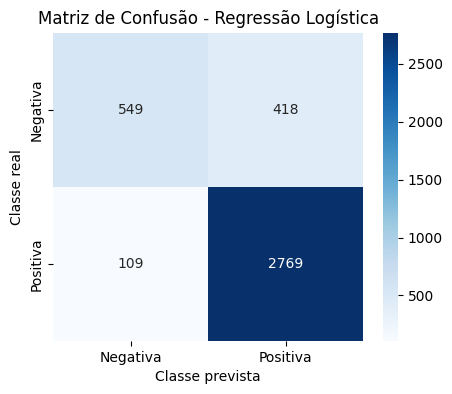

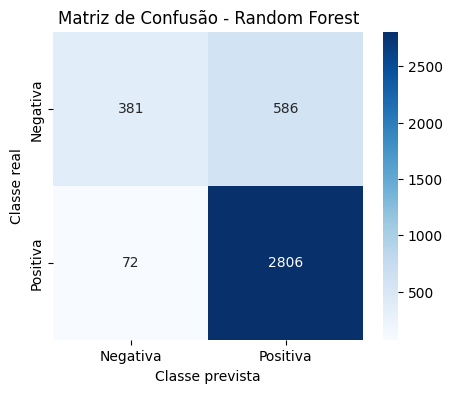

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

matrizes = {
    "Multinomial Naive Bayes": confusion_matrix(y_teste, previsoes_nb),
    "Regressão Logística": confusion_matrix(y_teste, previsoes_lr),
    "Random Forest": confusion_matrix(y_teste, previsoes_rf)
}

for nome, matriz in matrizes.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negativa", "Positiva"],
        yticklabels=["Negativa", "Positiva"]
    )
    
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.show()

## 38. Avaliação por classe

Como a base possui uma distribuição diferente entre avaliações positivas e negativas, as métricas também serão analisadas separadamente para cada classe.

Essa análise permite verificar o desempenho dos modelos tanto na identificação das recomendações positivas quanto das recomendações negativas.

In [54]:
from sklearn.metrics import classification_report

for nome, previsoes in modelos.items():
    print(f"\n{'=' * 60}")
    print(nome)
    print(f"{'=' * 60}")
    
    print(
        classification_report(
            y_teste,
            previsoes,
            target_names=["Negativa", "Positiva"],
            digits=4
        )
    )


Multinomial Naive Bayes
              precision    recall  f1-score   support

    Negativa     0.9043    0.4105    0.5647       967
    Positiva     0.8326    0.9854    0.9026      2878

    accuracy                         0.8408      3845
   macro avg     0.8685    0.6980    0.7337      3845
weighted avg     0.8507    0.8408    0.8176      3845


Regressão Logística
              precision    recall  f1-score   support

    Negativa     0.8343    0.5677    0.6757       967
    Positiva     0.8688    0.9621    0.9131      2878

    accuracy                         0.8629      3845
   macro avg     0.8516    0.7649    0.7944      3845
weighted avg     0.8602    0.8629    0.8534      3845


Random Forest
              precision    recall  f1-score   support

    Negativa     0.8411    0.3940    0.5366       967
    Positiva     0.8272    0.9750    0.8951      2878

    accuracy                         0.8289      3845
   macro avg     0.8342    0.6845    0.7158      3845
weighted avg 

## 39. Resumo dos resultados

A tabela abaixo reúne as principais métricas obtidas pelos modelos no conjunto de teste. Os resultados serão utilizados para comparar o desempenho dos classificadores e analisar o comportamento das previsões.

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []

for nome, previsoes in modelos.items():
    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_teste, previsoes),
        "Precisão": precision_score(y_teste, previsoes),
        "Recall": recall_score(y_teste, previsoes),
        "F1-Score": f1_score(y_teste, previsoes)
    })

df_resultados = pd.DataFrame(resultados)

df_resultados.style.format({
    "Acurácia": "{:.2%}",
    "Precisão": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}"
})

,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Multinomial Naive Bayes,84.08%,83.26%,98.54%,90.26%
1,Regressão Logística,86.29%,86.88%,96.21%,91.31%
2,Random Forest,82.89%,82.72%,97.50%,89.51%


## 40. Avaliação das recomendações negativas

Como as avaliações negativas representam uma parcela menor da base, será analisado separadamente o desempenho dos modelos nessa classe.

Essa análise permite verificar a capacidade dos modelos de identificar corretamente avaliações negativas, além das métricas gerais apresentadas anteriormente.

In [56]:
resultados_negativas = []

for nome, previsoes in modelos.items():
    relatorio = classification_report(
        y_teste,
        previsoes,
        output_dict=True
    )

    resultados_negativas.append({
        "Modelo": nome,
        "Precisão - Negativa": relatorio["0"]["precision"],
        "Recall - Negativa": relatorio["0"]["recall"],
        "F1-Score - Negativa": relatorio["0"]["f1-score"]
    })

df_negativas = pd.DataFrame(resultados_negativas)

df_negativas.style.format({
    "Precisão - Negativa": "{:.2%}",
    "Recall - Negativa": "{:.2%}",
    "F1-Score - Negativa": "{:.2%}"
})

,Modelo,Precisão - Negativa,Recall - Negativa,F1-Score - Negativa
0,Multinomial Naive Bayes,90.43%,41.05%,56.47%
1,Regressão Logística,83.43%,56.77%,67.57%
2,Random Forest,84.11%,39.40%,53.66%


## 41. Considerações sobre os resultados

Os três modelos apresentaram acurácia superior a 80% no conjunto de teste. As acurácias obtidas foram de 84,08% para o Multinomial Naive Bayes, 86,29% para a Regressão Logística e 82,89% para o Random Forest.

A análise das métricas por classe mostrou que os modelos apresentam maior capacidade de identificação das avaliações positivas do que das negativas. Na classe negativa, os valores de Recall e F1-Score foram menores, indicando maior dificuldade na identificação desse grupo.

Essa diferença está relacionada à distribuição da base, que possui 74,86% de avaliações positivas e 25,14% de avaliações negativas.

Os resultados obtidos nesta etapa serão utilizados como base para a continuidade do projeto e para a análise dos modelos nas próximas etapas.